# ARIMA-Tools: Development and Testing

**Miguel A. Arranz**  
**Applied Time Series Econometrics (ATSE)**

---

This notebook is used for the development, testing, and validation of the
`ARIMA-Tools` Python library.

The library provides teaching-oriented tools for empirical ARIMA modelling,
complementing functionality available in `statsmodels` and `statsforecast`.

## Development objectives

The main areas of development are:

- AR and MA root diagnostics
- Causality and invertibility
- Common and near-common roots
- Residual diagnostics
- Recursive estimation and parameter stability
- Model selection
- Static and multi-step forecasting
- Reconstruction of forecasts on the original scale

Forecast evaluation and model comparison will be handled separately by
`Forecast-Tools`.

---

**Status:** Under development

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd

from statsmodels.tsa.arima.model import ARIMA

import arima_tools as at

/opt/homebrew/Caskroom/miniforge/base/envs/atse_arma_tools/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Simulated ARMA(1,1) Proecess

In [2]:
from statsmodels.tsa.arima_process import ArmaProcess

np.random.seed(12345)

# y_t = 0.7 y_{t-1} + eps_t + 0.4 eps_{t-1}
ar = np.array([1, -0.7])
ma = np.array([1, 0.4])

process = ArmaProcess(ar, ma)
y = process.generate_sample(nsample=1000)

result = ARIMA(y, order=(1, 0, 1), trend="n").fit()

print(result.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1000
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1398.570
Date:                Sun, 04 Oct 2026   AIC                           2803.140
Time:                        15:49:05   BIC                           2817.863
Sample:                             0   HQIC                          2808.735
                               - 1000                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.6815      0.028     24.324      0.000       0.627       0.736
ma.L1          0.4130      0.035     11.948      0.000       0.345       0.481
sigma2         0.9588      0.042     22.892      0.0

In [3]:
print("AR parameters:", result.arparams)
print("MA parameters:", result.maparams)

print("AR roots:", result.arroots)
print("MA roots:", result.maroots)

AR parameters: [0.68146324]
MA parameters: [0.41301678]
AR roots: [1.46743059]
MA roots: [-2.42120913]


In [4]:
roots = at.root_diagnostics(result)
roots

,Type,Root,Value,Modulus,Inverse Root,Inverse Modulus
0,AR,1,1.467431,1.467431,0.681463,0.681463
1,MA,1,-2.421209,2.421209,-0.413017,0.413017


In [5]:
print("Causal:", at.is_causal(result))
print("Invertible:", at.is_invertible(result))

Causal: True
Invertible: True


In [6]:
at.common_roots(result)

,AR Root,MA Root,AR Inverse Root,MA Inverse Root,Distance,Classification


In [7]:
at.common_roots(result, tol=2.0)

,AR Root,MA Root,AR Inverse Root,MA Inverse Root,Distance,Classification
0,1,1,0.681463,-0.413017,1.09448,Near-common


In [8]:
at.root_summary(result)

Causal AR component        True
Invertible MA component    True
Common root pairs             0
Near-common root pairs        0
Minimum AR-MA distance      NaN
Name: Root diagnostics, dtype: object

In [9]:
at.coefficient_diagnostics(result)

,Coefficient,Estimate,Std. Error,z-statistic,P-value,95% CI Lower,95% CI Upper
0,ar.L1,0.681463,0.028016,24.323711,1.100401e-130,0.626552,0.736374
1,ma.L1,0.413017,0.034568,11.947951,6.654539e-33,0.345265,0.480769
2,sigma2,0.958818,0.041884,22.892302,5.543601e-116,0.876727,1.040909


In [10]:
at.parameter_correlation(result)

,ar.L1,ma.L1
ar.L1,1.000000,-0.507281
ma.L1,-0.507281,1.000000


In [11]:
at.parameter_correlation(result, include_variance=True)

,ar.L1,ma.L1,sigma2
ar.L1,1.000000,-0.507281,-0.021023
ma.L1,-0.507281,1.000000,-0.035651
sigma2,-0.021023,-0.035651,1.000000


In [12]:
at.ljung_box_test(result, lags=[5, 10, 20])

,Ljung-Box statistic,Degrees of freedom,P-value
Lag,,,
5,0.336264,3,0.953070
10,4.263639,8,0.832588
20,12.981030,18,0.792699


In [13]:
#at.ljung_box_test(result, lags=[1, 2, 5, 10])

In [14]:
at.residual_correlations(result, lags=20)

,Lag,ACF,PACF,Lower Bound,Upper Bound
0,1,0.004407,0.004407,-0.06198,0.06198
1,2,0.001682,0.001663,-0.06198,0.06198
2,3,-0.013058,-0.013073,-0.06198,0.06198
3,4,0.011889,0.012004,-0.06198,0.06198
4,5,0.000614,0.000551,-0.06198,0.06198
5,6,-0.000006,-0.000223,-0.06198,0.06198
6,7,0.037581,0.037906,-0.06198,0.06198
7,8,-0.033217,-0.033749,-0.06198,0.06198
8,9,-0.034616,-0.034512,-0.06198,0.06198
9,10,-0.013194,-0.011754,-0.06198,0.06198


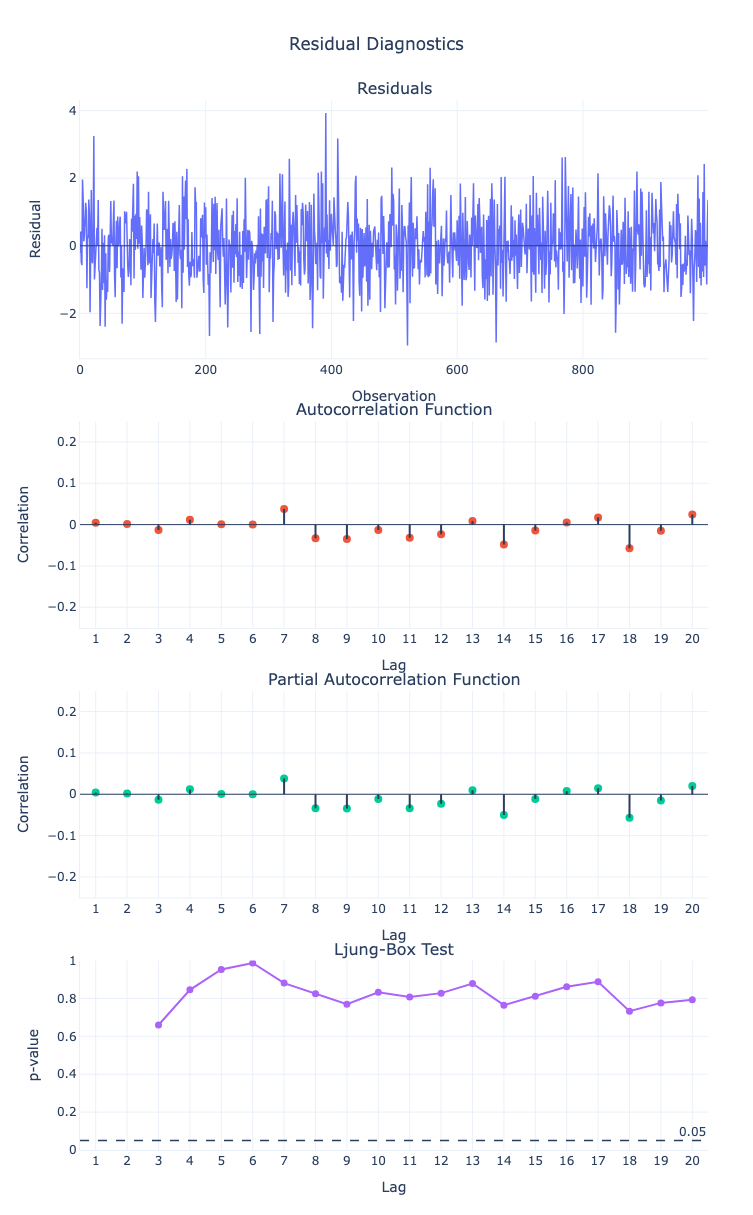

In [15]:
at.plot_residual_diagnostics(
    result,
    lags=20,
)

In [16]:
at.jarque_bera_test(result)

Jarque-Bera statistic    4.148883
Degrees of freedom       2.000000
P-value                  0.125627
Skewness                 0.149108
Kurtosis                 3.110988
Name: Jarque-Bera test, dtype: float64

In [17]:
at.dynamic_effects(result, horizon=20)

,Horizon,Dynamic Effect,Cumulative Effect
0,0,1.000000,1.000000
1,1,1.094480,2.094480
2,2,0.745848,2.840328
3,3,0.508268,3.348596
4,4,0.346366,3.694962
5,5,0.236036,3.930997
6,6,0.160850,4.091847
7,7,0.109613,4.201460
8,8,0.074697,4.276157
9,9,0.050903,4.327061


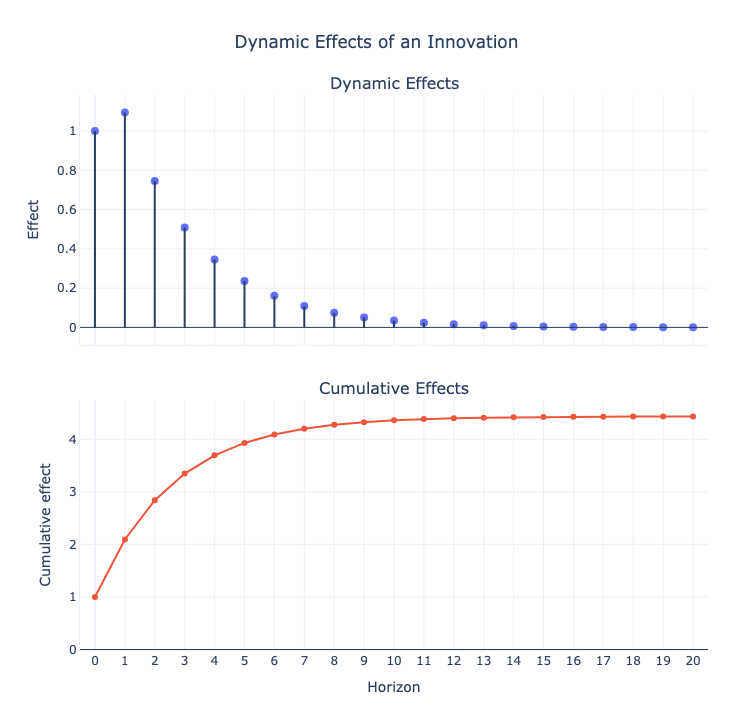

In [18]:
at.plot_dynamic_effects(
    result,
    horizon=20,
)

## Near-common roots

In [19]:
np.random.seed(2468)

# Near-cancelling ARMA(1,1):
# AR inverse root = 0.70
# MA inverse root = 0.68
ar_near = np.array([1, -0.70])
ma_near = np.array([1, -0.68])

process_near = ArmaProcess(ar_near, ma_near)
y_near = process_near.generate_sample(nsample=2000)

result_near = ARIMA(
    y_near,
    order=(1, 0, 1),
    trend="n"
).fit()

print("AR parameter:", result_near.arparams)
print("MA parameter:", result_near.maparams)

at.root_diagnostics(result_near)

AR parameter: [0.43039912]
MA parameter: [-0.40549696]


,Type,Root,Value,Modulus,Inverse Root,Inverse Modulus
0,AR,1,2.323425,2.323425,0.430399,0.430399
1,MA,1,2.466110,2.466110,0.405497,0.405497


In [20]:
at.common_roots(result_near, tol=0.05)

,AR Root,MA Root,AR Inverse Root,MA Inverse Root,Distance,Classification
0,1,1,0.430399,0.405497,0.024902,Near-common


In [21]:
at.root_summary(result_near)

Causal AR component            True
Invertible MA component        True
Common root pairs                 0
Near-common root pairs            1
Minimum AR-MA distance     0.024902
Name: Root diagnostics, dtype: object

In [22]:
at.parameter_correlation(result_near)

,ar.L1,ma.L1
ar.L1,1.000000,-0.999604
ma.L1,-0.999604,1.000000


In [23]:
at.ljung_box_test(result_near, lags=[5, 10, 20])

,Ljung-Box statistic,Degrees of freedom,P-value
Lag,,,
5,3.697160,3,0.296077
10,14.798773,8,0.063178
20,17.604941,18,0.481949


In [24]:
at.residual_correlations(result_near, lags=20)

,Lag,ACF,PACF,Lower Bound,Upper Bound
0,1,-0.001028,-0.001028,-0.043826,0.043826
1,2,-0.007978,-0.007979,-0.043826,0.043826
2,3,0.022316,0.022301,-0.043826,0.043826
3,4,-0.012212,-0.012241,-0.043826,0.043826
4,5,-0.033629,-0.033315,-0.043826,0.043826
5,6,0.007125,0.006391,-0.043826,0.043826
6,7,-0.030812,-0.030826,-0.043826,0.043826
7,8,0.043669,0.045187,-0.043826,0.043826
8,9,0.050257,0.048890,-0.043826,0.043826
9,10,-0.009450,-0.008352,-0.043826,0.043826


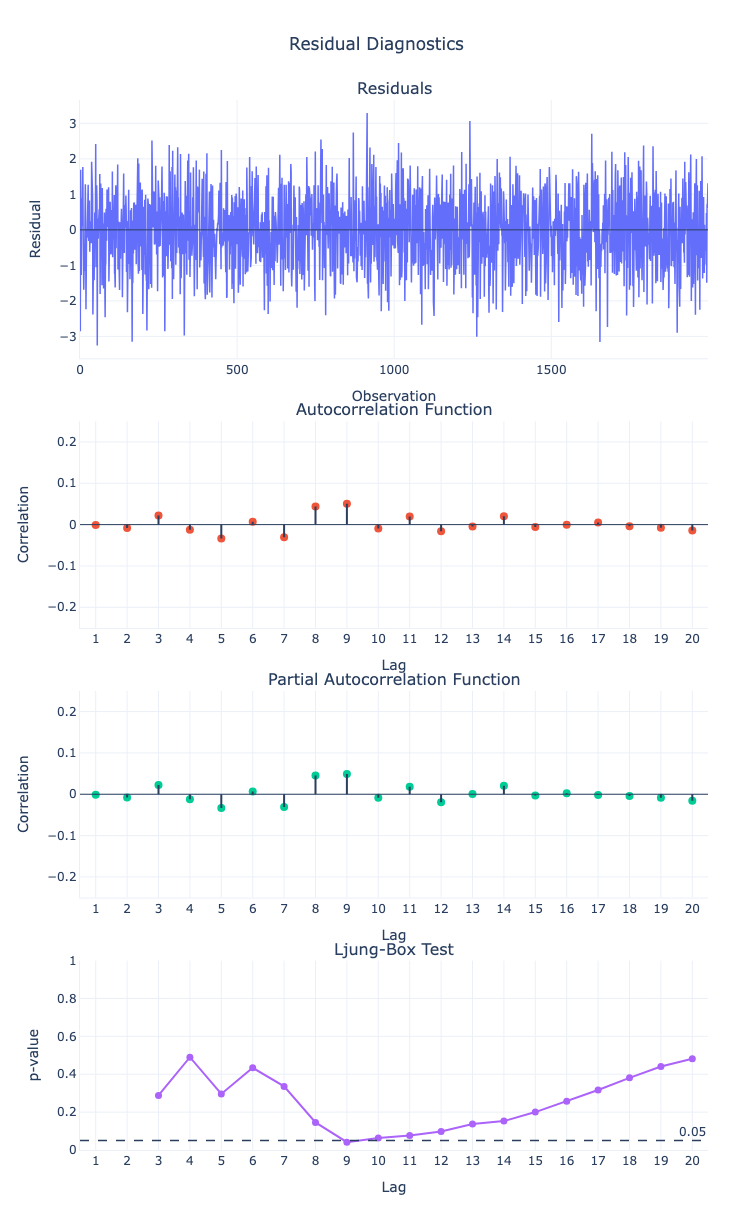

In [25]:
at.plot_residual_diagnostics(
    result_near,
    lags=20,
)

In [26]:
at.jarque_bera_test(result_near)

Jarque-Bera statistic    2.477895
Degrees of freedom       2.000000
P-value                  0.289689
Skewness                -0.068627
Kurtosis                 2.898225
Name: Jarque-Bera test, dtype: float64

In [27]:
at.dynamic_effects(result_near, horizon=20)

,Horizon,Dynamic Effect,Cumulative Effect
0,0,1.000000e+00,1.000000
1,1,2.490216e-02,1.024902
2,2,1.071787e-02,1.035620
3,3,4.612961e-03,1.040233
4,4,1.985415e-03,1.042218
5,5,8.545207e-04,1.043073
6,6,3.677849e-04,1.043441
7,7,1.582943e-04,1.043599
8,8,6.812974e-05,1.043667
9,9,2.932298e-05,1.043696


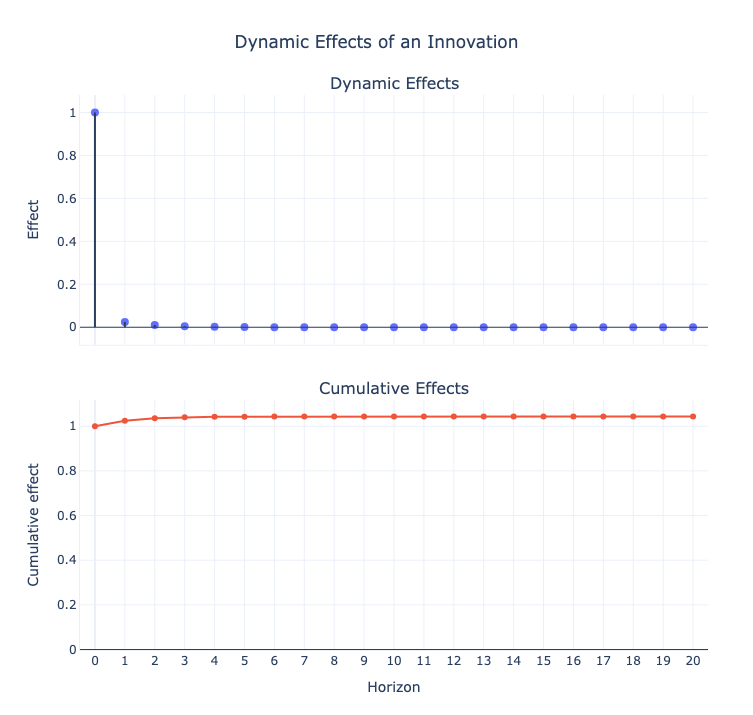

In [28]:
at.plot_dynamic_effects(
    result_near,
    horizon=20,
)

## AR(2) Complex Roots

In [29]:
np.random.seed(1357)

# AR(2) with complex-conjugate roots
# y_t = 1.2 y_{t-1} - 0.5 y_{t-2} + eps_t
ar_complex = np.array([1, -1.2, 0.5])
ma_complex = np.array([1])

process_complex = ArmaProcess(ar_complex, ma_complex)
y_complex = process_complex.generate_sample(nsample=2000)

result_complex = ARIMA(
    y_complex,
    order=(2, 0, 0),
    trend="n"
).fit()

print("AR parameters:", result_complex.arparams)

at.root_diagnostics(result_complex)

AR parameters: [ 1.21813126 -0.50164691]


,Type,Root,Value,Modulus,Inverse Root,Inverse Modulus
0,AR,1,1.214132-0.720637j,1.41189,0.609066+0.361505j,0.70827
1,AR,2,1.214132+0.720637j,1.41189,0.609066-0.361505j,0.70827


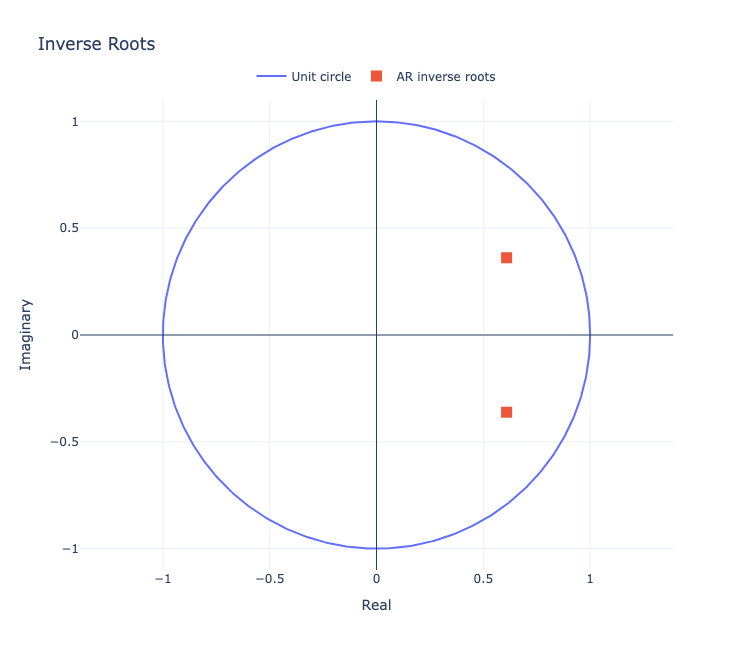

In [30]:
at.plot_inverse_roots(result_complex)

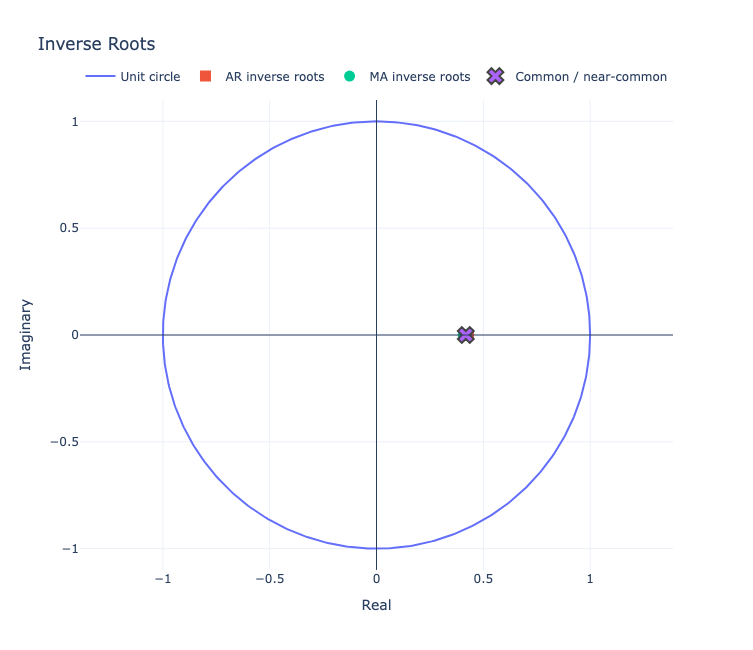

In [31]:
at.plot_inverse_roots(result_near)

In [32]:
at.root_summary(result_complex)

Causal AR component        True
Invertible MA component    True
Common root pairs             0
Near-common root pairs        0
Minimum AR-MA distance      NaN
Name: Root diagnostics, dtype: object

In [33]:
at.parameter_correlation(result_complex)

,ar.L1,ar.L2
ar.L1,1.000000,-0.812501
ar.L2,-0.812501,1.000000


In [34]:
at.joint_significance(
    result_complex,
    ["ar.L1", "ar.L2"]
)

Wald statistic        6186.003966
Degrees of freedom       2.000000
P-value                  0.000000
Name: Joint significance test, dtype: float64

In [35]:
at.ljung_box_test(result_complex, lags=[5, 10, 20])

,Ljung-Box statistic,Degrees of freedom,P-value
Lag,,,
5,1.785702,3,0.618051
10,4.954630,8,0.762414
20,11.922463,18,0.851215


In [36]:
at.residual_correlations(result_complex, lags=20)

,Lag,ACF,PACF,Lower Bound,Upper Bound
0,1,0.002885,0.002885,-0.043826,0.043826
1,2,0.000223,0.000215,-0.043826,0.043826
2,3,-0.017907,-0.017908,-0.043826,0.043826
3,4,-0.004654,-0.004552,-0.043826,0.043826
4,5,0.023225,0.023268,-0.043826,0.043826
5,6,-0.011008,-0.011470,-0.043826,0.043826
6,7,-0.011423,-0.011553,-0.043826,0.043826
7,8,-0.003803,-0.002909,-0.043826,0.043826
8,9,-0.032242,-0.032430,-0.043826,0.043826
9,10,-0.016441,-0.017343,-0.043826,0.043826


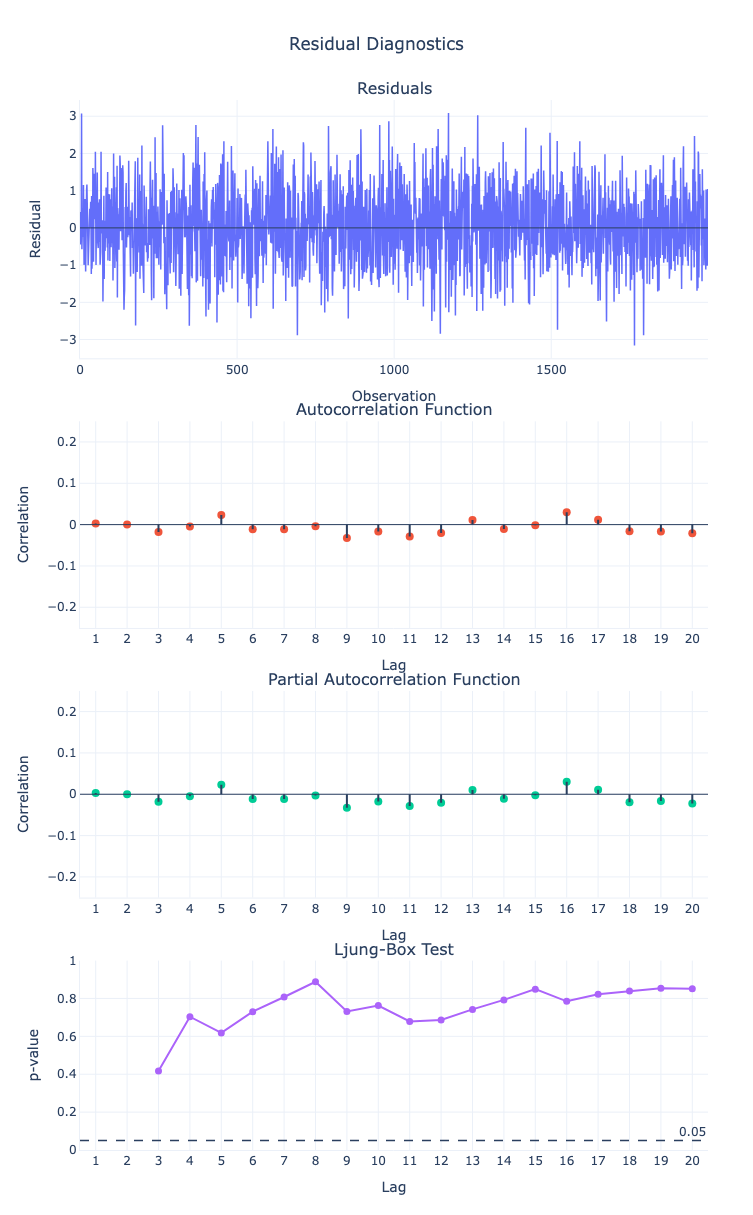

In [37]:
at.plot_residual_diagnostics(
    result_complex,
    lags=20,
)

In [38]:
at.jarque_bera_test(result_complex)

Jarque-Bera statistic    2.074076
Degrees of freedom       2.000000
P-value                  0.354503
Skewness                 0.051777
Kurtosis                 2.883622
Name: Jarque-Bera test, dtype: float64

In [39]:
at.dynamic_effects(result_complex, horizon=20)

,Horizon,Dynamic Effect,Cumulative Effect
0,0,1.000000,1.000000
1,1,1.218131,2.218131
2,2,0.982197,3.200328
3,3,0.585373,3.785701
4,4,0.220345,4.006046
5,5,-0.025241,3.980805
6,6,-0.141283,3.839522
7,7,-0.159439,3.680083
8,8,-0.123343,3.556740
9,9,-0.070266,3.486474


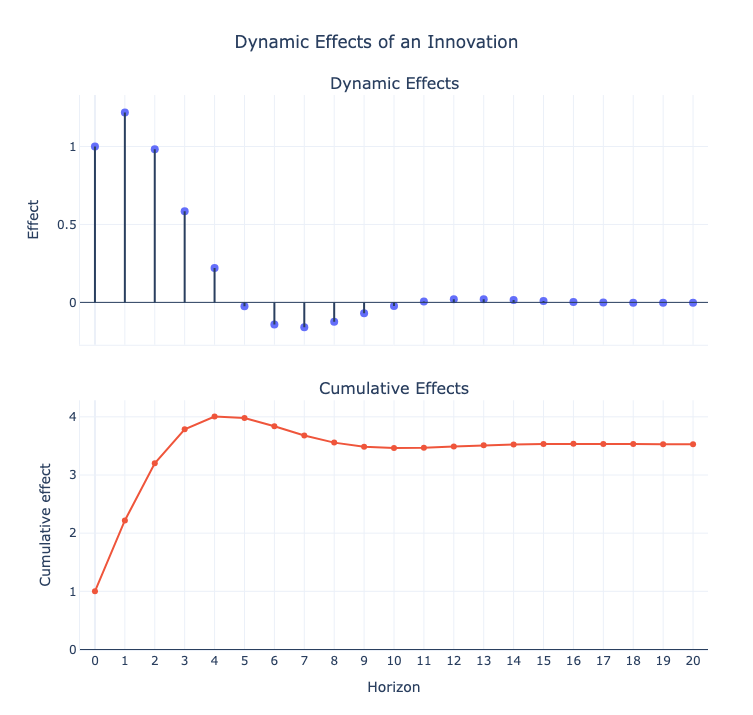

In [40]:
at.plot_dynamic_effects(
    result_complex,
    horizon=20,
)

In [41]:
at.compare_models(
    result,
    result_complex,
    names=["ARMA(1,1)", "AR(2)"],
)

,Order,N,Parameters,Log Likelihood,AIC,AICc,BIC,HQIC
Model,,,,,,,,
"ARMA(1,1)","(1, 0, 1)",1000,3,-1398.569800,2803.139600,2803.163696,2817.862866,2808.735468
AR(2),"(2, 0, 0)",2000,3,-2816.229994,5638.459988,5638.472012,5655.262696,5644.629590


In [42]:
search = at.order_search(
    y,
    p_max=3,
    q_max=3,
    criterion="BIC",
)

search

,Order,p,d,q,N,Parameters,Log Likelihood,AIC,AICc,BIC,HQIC,Converged,Status
0,"(1, 0, 1)",1,0,1,1000,4,-1398.565862,2805.131724,2805.171925,2824.762745,2812.592882,True,OK
1,"(1, 0, 2)",1,0,2,1000,5,-1398.485915,2806.971829,2807.032192,2831.510606,2816.298277,True,OK
2,"(2, 0, 1)",2,0,1,1000,5,-1398.492125,2806.984250,2807.044612,2831.523026,2816.310697,True,OK
3,"(3, 0, 0)",3,0,0,1000,5,-1399.326571,2808.653142,2808.713504,2833.191918,2817.979589,True,OK
4,"(1, 0, 3)",1,0,3,1000,6,-1398.423409,2808.846818,2808.931410,2838.293350,2820.038555,True,OK
5,"(3, 0, 1)",3,0,1,1000,6,-1398.423706,2808.847412,2808.932004,2838.293944,2820.039149,True,OK
6,"(2, 0, 2)",2,0,2,1000,6,-1398.457237,2808.914473,2808.999065,2838.361005,2820.106210,True,OK
7,"(2, 0, 0)",2,0,0,1000,4,-1406.969603,2821.939206,2821.979407,2841.570227,2829.400364,True,OK
8,"(3, 0, 2)",3,0,2,1000,7,-1398.414339,2810.828677,2810.941580,2845.182964,2823.885703,True,OK
9,"(2, 0, 3)",2,0,3,1000,7,-1398.423029,2810.846059,2810.958962,2845.200346,2823.903085,True,OK


In [43]:
print(search.loc[0, "Status"])

OK


In [44]:
at.select_model(search, criterion="BIC")

Order               (1, 0, 1)
p                           1
d                           0
q                           1
N                        1000
Parameters                  4
Log Likelihood   -1398.565862
AIC               2805.131724
AICc              2805.171925
BIC               2824.762745
HQIC              2812.592882
Converged                True
Status                     OK
Name: 0, dtype: object

In [45]:
search_i1 = at.order_search(
    y_complex,
    p_max=3,
    q_max=3,
    d_min=1,
    d_max=1,
    criterion="BIC",
)

search_i1

,Order,p,d,q,N,Parameters,Log Likelihood,AIC,AICc,BIC,HQIC,Converged,Status
0,"(2, 1, 1)",2,1,1,2000,4,-2816.627570,5641.255141,5641.275191,5663.656750,5649.480750,True,OK
1,"(3, 1, 1)",3,1,1,2000,5,-2816.582942,5643.165884,5643.195975,5671.167896,5653.447896,True,OK
2,"(2, 1, 2)",2,1,2,2000,5,-2816.584699,5643.169397,5643.199487,5671.171409,5653.451409,True,OK
3,"(3, 1, 2)",3,1,2,2000,6,-2815.683236,5643.366472,5643.408620,5676.968886,5655.704887,True,OK
4,"(2, 1, 3)",2,1,3,2000,6,-2816.429201,5644.858402,5644.900550,5678.460816,5657.196816,True,OK
5,"(1, 1, 3)",1,1,3,2000,5,-2838.435118,5686.870236,5686.900326,5714.872247,5697.152247,True,OK
6,"(1, 1, 2)",1,1,2,2000,4,-2886.379625,5780.759250,5780.779301,5803.160860,5788.984860,True,OK
7,"(3, 1, 0)",3,1,0,2000,4,-2975.718451,5959.436902,5959.456952,5981.838511,5967.662511,True,OK
8,"(2, 1, 0)",2,1,0,2000,3,-3011.733465,6029.466930,6029.478954,6046.268137,6035.636137,True,OK
9,"(0, 1, 3)",0,1,3,2000,4,-3010.449768,6028.899535,6028.919585,6051.301145,6037.125145,True,OK


In [46]:
search_all = at.order_search(
    y_complex,
    p_max=3,
    q_max=3,
    d_min=0,
    d_max=2,
    criterion="BIC",
)

search_all

,Order,p,d,q,N,Parameters,Log Likelihood,AIC,AICc,BIC,HQIC,Converged,Status
0,"(2, 0, 0)",2,0,0,2000,4,-2814.988647,5637.977293,5637.997343,5660.380903,5646.203429,True,OK
1,"(2, 1, 1)",2,1,1,2000,4,-2816.627570,5641.255141,5641.275191,5663.656750,5649.480750,True,OK
2,"(3, 0, 0)",3,0,0,2000,5,-2814.952510,5639.905019,5639.935110,5667.909532,5650.187689,True,OK
3,"(2, 0, 1)",2,0,1,2000,5,-2814.953913,5639.907827,5639.937917,5667.912339,5650.190497,True,OK
4,"(3, 1, 1)",3,1,1,2000,5,-2816.582942,5643.165884,5643.195975,5671.167896,5653.447896,True,OK
5,"(2, 1, 2)",2,1,2,2000,5,-2816.584699,5643.169397,5643.199487,5671.171409,5653.451409,True,OK
6,"(2, 0, 2)",2,0,2,2000,6,-2814.812376,5641.624753,5641.666900,5675.230167,5653.963956,True,OK
7,"(3, 0, 1)",3,0,1,2000,6,-2814.988601,5641.977202,5642.019349,5675.582616,5654.316405,True,OK
8,"(3, 1, 2)",3,1,2,2000,6,-2815.683236,5643.366472,5643.408620,5676.968886,5655.704887,True,OK
9,"(2, 1, 3)",2,1,3,2000,6,-2816.429201,5644.858402,5644.900550,5678.460816,5657.196816,True,OK


In [47]:
at.select_model(
    search_all,
    criterion="BIC",
)

Order               (2, 0, 0)
p                           2
d                           0
q                           0
N                        2000
Parameters                  4
Log Likelihood   -2814.988647
AIC               5637.977293
AICc              5637.997343
BIC               5660.380903
HQIC              5646.203429
Converged                True
Status                     OK
Name: 0, dtype: object

### Auto.Arima

In [48]:
auto = at.auto_arima(
    y_complex,
    criterion="BIC",
)

auto

AutoARIMA

In [49]:
hasattr(auto, "model_")

True

In [50]:
type(auto)

statsforecast.models.AutoARIMA

In [51]:
auto.__dict__.keys()

dict_keys(['d', 'D', 'max_p', 'max_q', 'max_P', 'max_Q', 'max_order', 'max_d', 'max_D', 'start_p', 'start_q', 'start_P', 'start_Q', 'stationary', 'seasonal', 'ic', 'stepwise', 'nmodels', 'trace', 'approximation', 'method', 'truncate', 'test', 'test_kwargs', 'seasonal_test', 'seasonal_test_kwargs', 'allowdrift', 'allowmean', 'blambda', 'biasadj', 'season_length', 'distribution', 'alias', 'prediction_intervals', 'model_'])

In [52]:
auto.model_.keys()

dict_keys(['coef', 'sigma2', 'var_coef', 'mask', 'loglik', 'aic', 'arma', 'residuals', 'code', 'n_cond', 'nobs', 'model', 'distribution', 'bic', 'aicc', 'ic', 'xreg', 'x', 'lambda'])

In [53]:
at.arima_string(auto.model_)

'ARIMA(2,0,0) with zero mean    '

In [54]:
for key in [
    "ic",
    "aic",
    "aicc",
    "bic",
    "loglik",
    "nobs",
    "sigma2",
]:
    print(key, ":", auto.model_.get(key))

ic : None
aic : 5638.459987990459
aicc : 5638.4720120385555
bic : 5655.262695369085
loglik : -2816.2299939952295
nobs : 2000
sigma2 : 0.9787559089854494


In [55]:
at.auto_arima_summary(auto)

Selected model                        ARIMA(2,0,0)
Deterministic component                       None
Interpretation             Zero unconditional mean
Selection criterion                            BIC
Criterion value                        5655.262695
AIC                                    5638.459988
AICc                                   5638.472012
BIC                                    5655.262695
Log Likelihood                        -2816.229994
Observations                                  2000
Innovation variance                       0.978756
Name: AutoARIMA Summary, dtype: object

### Recursive Estimation

In [56]:
recursive = at.recursive_estimation(
    y_complex,
    order=(2, 0, 0),
)

recursive.head(10)

,Endpoint,N,Parameter,Estimate,Std. Error,Lower CI,Upper CI,Converged
0,199,200,const,0.323671,0.216047,-0.099773,0.747116,True
1,199,200,ar.L1,1.258034,0.049107,1.161785,1.354282,True
2,199,200,ar.L2,-0.560557,0.057522,-0.673299,-0.447815,True
3,199,200,sigma2,0.838604,0.081266,0.679325,0.997883,True
4,200,201,const,0.308488,0.214294,-0.111521,0.728497,True
5,200,201,ar.L1,1.256361,0.049124,1.160080,1.352642,True
6,200,201,ar.L2,-0.561121,0.057531,-0.673881,-0.448362,True
7,200,201,sigma2,0.838697,0.081281,0.679389,0.998004,True
8,201,202,const,0.285568,0.213550,-0.132982,0.704117,True
9,201,202,ar.L1,1.262031,0.049435,1.165140,1.358921,True


In [57]:
recursive["N"].min()

np.int64(200)

In [58]:
recursive.groupby("N")["Converged"].first().value_counts()

Converged
True    1801
Name: count, dtype: int64

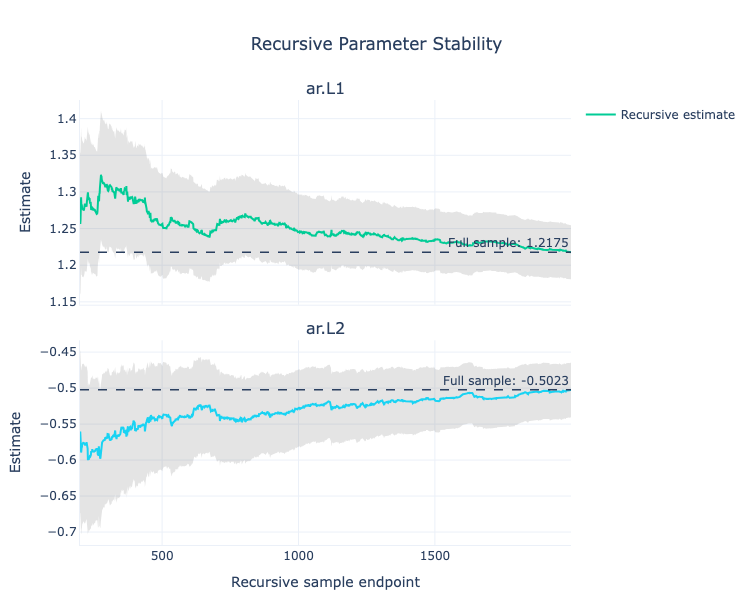

In [59]:
at.plot_parameter_stability(
    recursive,
    parameters=["ar.L1", "ar.L2"],
)

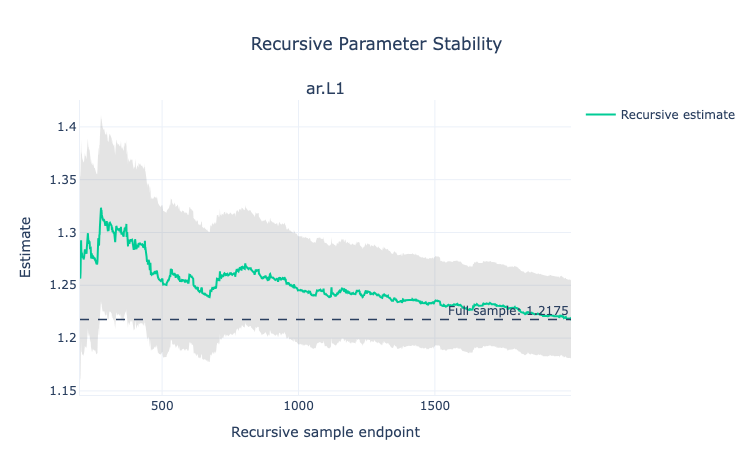

In [60]:
at.plot_parameter_stability(
    recursive,
    parameters="ar.L1",
)

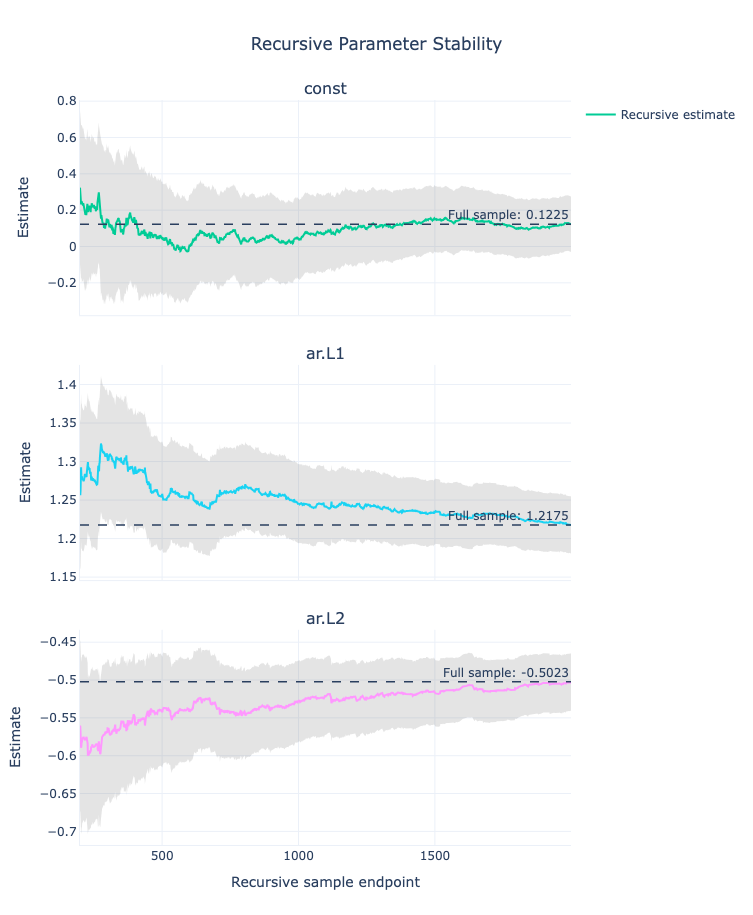

In [61]:
at.plot_parameter_stability(
    recursive,
)

## Simulated Structural Break

In [62]:
# ------------------------------------------------------------
# Structural-break test: AR(1)
# ------------------------------------------------------------

rng = np.random.default_rng(12345)

T = 500
break_point = 300

phi_1 = 0.40
phi_2 = 0.85

eps = rng.normal(size=T)
y_break = np.zeros(T)

for t in range(1, T):
    phi = phi_1 if t < break_point else phi_2
    y_break[t] = phi * y_break[t - 1] + eps[t]

y_break = pd.Series(
    y_break,
    index=pd.RangeIndex(start=1, stop=T + 1),
    name="y",
)

In [63]:
from statsmodels.tsa.arima.model import ARIMA

pre = ARIMA(
    y_break.iloc[:break_point],
    order=(1, 0, 0),
).fit()

post = ARIMA(
    y_break.iloc[break_point:],
    order=(1, 0, 0),
).fit()

print("Pre-break AR coefficient :", pre.arparams[0])
print("Post-break AR coefficient:", post.arparams[0])

Pre-break AR coefficient : 0.41917394731325136
Post-break AR coefficient: 0.8598655475742253


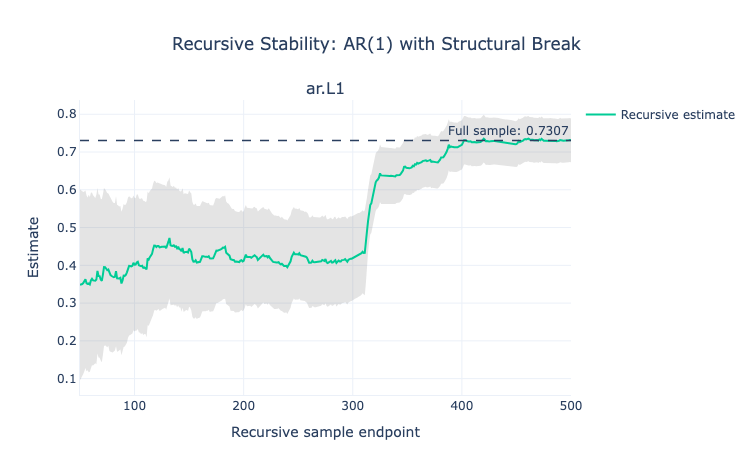

In [64]:
recursive_break = at.recursive_estimation(
    y_break,
    order=(1, 0, 0),
)

at.plot_parameter_stability(
    recursive_break,
    parameters="ar.L1",
    title="Recursive Stability: AR(1) with Structural Break",
)

In [65]:
recursive_break["N"].min()

np.int64(50)

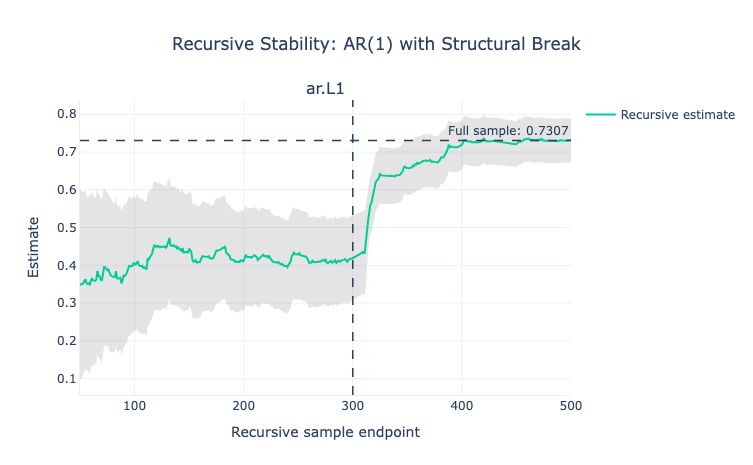

In [66]:
at.plot_parameter_stability(
    recursive_break,
    parameters="ar.L1",
    breakpoint=300,
    title="Recursive Stability: AR(1) with Structural Break",
)

## I(1) Process Auto.Arima

In [67]:
# ------------------------------------------------------------
# I(1) process with drift
# ------------------------------------------------------------

rng = np.random.default_rng(24680)

T = 500
drift = 0.20

eps = rng.normal(size=T)

y_drift = np.zeros(T)

for t in range(1, T):
    y_drift[t] = (
        y_drift[t - 1]
        + drift
        + eps[t]
    )

y_drift = pd.Series(
    y_drift,
    name="y_drift",
)

In [68]:
auto_drift = at.auto_arima(
    y_drift,
    criterion="BIC",
)

at.auto_arima_summary(auto_drift)

Selected model                                                  ARIMA(0,1,0)
Deterministic component                                                Drift
Interpretation             Constant in differenced model; linear drift in...
Selection criterion                                                      BIC
Criterion value                                                  1478.384383
AIC                                                              1469.959171
AICc                                                             1469.983364
BIC                                                              1478.384383
Log Likelihood                                                   -732.979585
Observations                                                             499
Innovation variance                                                   1.1094
Name: AutoARIMA Summary, dtype: object

In [69]:
print(at.auto_arima_summary(auto_drift)["Interpretation"])

Constant in differenced model; linear drift in level
